# Water Level Prediction Pipeline
## BBWS Bengawan Solo — TMA Prediction

Modular, reproducible ML pipeline for competition submission.

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.utils import set_seed, evaluate, print_metrics, reduce_mem_usage

set_seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print(f'Project root: {PROJECT_ROOT}')
print('Setup complete.')

Project root: D:\Lomba\SSDS\Mandiri
Setup complete.


---
## Step 1: Load & Preprocess

Load all datasets, clean environment data, aggregate hourly to 6-hourly, extract river features, merge into master datasets.

In [2]:
from src.preprocess import run_preprocessing

master_train, master_test = run_preprocessing()

print('\n' + '='*60)
print('Master Train:', master_train.shape)
print('Master Test: ', master_test.shape)
print('='*60)

master_train.head()

Loading datasets...
  train: (84396, 3)
  test: (21780, 3)
  env: (888480, 27)
  coord: (30, 3)
  river: (836472, 15)

Cleaning environment data...
Cleaned env: (888480, 27), remaining NaN: 0

Aggregating environment data to 6-hourly...
Aggregated env: (111060, 26)

Extracting river features...
River features extracted for 30 stations.

Building spatial features...
Spatial features: (30, 16)

Merging master train...
Master shape: (84396, 42)

Merging master test...
Master shape: (21780, 42)

Master Train: (84396, 42)
Master Test:  (21780, 42)


,datetime,nama_pos,tma_mdpl,rainfall_mm,rainfall_openmeteo_mm,solar_radiation_mj_m2,humidity_pct,wind_direction_deg,dew_point_c,cloud_cover_pct,temperature_c,wind_speed_kmh,rainfall_max_24h_mm,soil_moisture_0_7cm,soil_moisture_7_28cm,soil_moisture_28_100cm,soil_moisture_100_255cm,surface_pressure_hpa,pressure_msl_hpa,rmm1,rmm2,mjo_phase,mjo_amplitude,mjo_active,nino_34,built_surface_m2,landcover_class,latitude,longitude,river_order,nearest_river_dist,river_length,upstream_area,river_discharge_avg,dist_to_ocean,dist_to_source,main_river_id,catchment_local,hydrobasin_id,river_strahler,station_cluster,nearest_station_dist
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.300,0.000,0.000,102.820,85.500,348.000,22.383,100.000,25.000,14.333,0.000,0.406,0.404,0.422,0.413,1008.867,1009.067,-0.092,1.278,7.000,1.281,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.200,0.700,0.700,3329.350,78.333,320.000,23.917,100.000,28.067,13.633,0.117,0.388,0.393,0.421,0.413,1010.483,1010.683,-0.092,1.278,7.000,1.281,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.500,3.400,3.400,1590.430,83.167,297.167,24.000,100.000,27.150,13.583,1.483,0.401,0.389,0.420,0.413,1008.833,1009.033,-0.092,1.278,7.000,1.281,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.450,0.100,0.100,68.850,90.500,326.500,22.883,100.000,24.567,11.967,1.700,0.391,0.382,0.414,0.413,1009.083,1009.283,-0.531,1.394,7.000,1.491,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.250,1.800,1.800,3350.750,77.000,289.167,23.450,100.000,27.883,21.350,1.700,0.391,0.384,0.412,0.413,1010.650,1010.850,-0.531,1.394,7.000,1.491,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065


In [3]:
# Reduce memory usage
master_train = reduce_mem_usage(master_train)
master_test = reduce_mem_usage(master_test)

Memory: 26.6 MB -> 14.6 MB (45.0% reduction)
Memory: 7.6 MB -> 4.5 MB (39.9% reduction)


---
## Step 2: Feature Engineering

Build all features: time, cyclic, lags, rolling, difference, cumulative, expanding, station encoding.

> **Important**: For the test set, we concatenate train+test history before building lag/rolling features to avoid NaN at boundaries.

In [4]:
from src.feature_engineering import build_all_features, get_feature_columns, get_categorical_features

# Save a copy of master_test BEFORE feature engineering (needed for test FE later)
master_test_raw = master_test.copy()

# Build features for TRAIN
master_train = build_all_features(master_train, is_train=True)

print('\nTrain columns:', master_train.shape[1])
master_train.head()

Building features...
  ✓ Time features
  ✓ Cyclic features
  ✓ Station encoding
  ✓ Station baselines
  ✓ Regional features
  ✓ Difference features
  ✓ Cumulative rainfall
  ✓ Environment lags
  ✓ Environment rolling
  ✓ Climate rolling
  ✓ Interaction features
Final shape: (84396, 104)

Train columns: 104


,datetime,nama_pos,tma_mdpl,rainfall_mm,rainfall_openmeteo_mm,solar_radiation_mj_m2,humidity_pct,wind_direction_deg,dew_point_c,cloud_cover_pct,temperature_c,wind_speed_kmh,rainfall_max_24h_mm,soil_moisture_0_7cm,soil_moisture_7_28cm,soil_moisture_28_100cm,soil_moisture_100_255cm,surface_pressure_hpa,pressure_msl_hpa,rmm1,rmm2,mjo_phase,mjo_amplitude,mjo_active,nino_34,built_surface_m2,landcover_class,latitude,longitude,river_order,nearest_river_dist,river_length,upstream_area,river_discharge_avg,dist_to_ocean,dist_to_source,main_river_id,catchment_local,hydrobasin_id,river_strahler,station_cluster,nearest_station_dist,hour,day,month,week,quarter,dayofyear,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dayofyear_sin,dayofyear_cos,station_encoded,station_mean_tma,station_min_tma,station_max_tma,regional_rainfall,runoff_potential,delta_rain_1,delta_pressure_1,rain_cumsum_48h,rain_cumsum_96h,rain_cumsum_144h,rain_cumsum_168h,rain_cumsum_336h,rainfall_mm_lag_1,rainfall_mm_lag_3,rainfall_mm_lag_6,rainfall_openmeteo_mm_lag_1,rainfall_openmeteo_mm_lag_3,rainfall_openmeteo_mm_lag_6,humidity_lag_1,soil_moisture_0_7cm_lag_1,soil_moisture_7_28cm_lag_1,soil_moisture_28_100cm_lag_1,soil_moisture_100_255cm_lag_1,rainfall_mm_roll_sum_6,rainfall_mm_roll_sum_12,rainfall_openmeteo_mm_roll_sum_6,rainfall_openmeteo_mm_roll_sum_12,soil_moisture_0_7cm_roll_mean_6,soil_moisture_7_28cm_roll_mean_6,soil_moisture_28_100cm_roll_mean_6,soil_moisture_100_255cm_roll_mean_6,rmm1_roll_mean_120,rmm1_roll_mean_240,rmm2_roll_mean_120,rmm2_roll_mean_240,mjo_phase_roll_mean_120,mjo_phase_roll_mean_240,mjo_amplitude_roll_mean_120,mjo_amplitude_roll_mean_240,mjo_active_roll_mean_120,mjo_active_roll_mean_240,nino_34_roll_mean_120,nino_34_roll_mean_240,rain_x_upstream,rain_48h_x_upstream,rain_7d_x_upstream,rain_14d_x_upstream
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.300,0.000,0.000,102.820,85.500,348.000,22.383,100.000,25.000,14.333,0.000,0.406,0.404,0.422,0.413,1008.867,1009.067,-0.092,1.278,7.000,1.281,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065,6,1,1,52,1,1,6,1,1.000,0.000,0.500,0.866,0.017,1.000,0,1.116,0.348,4.850,0.050,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.200,0.700,0.700,3329.350,78.333,320.000,23.917,100.000,28.067,13.633,0.117,0.388,0.393,0.421,0.413,1010.483,1010.683,-0.092,1.278,7.000,1.281,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065,12,1,1,52,1,1,6,1,0.000,-1.000,0.500,0.866,0.017,1.000,0,1.116,0.348,4.850,2.700,0.271,0.700,1.617,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,0.000,NaN,NaN,85.500,0.406,0.404,0.422,0.413,0.000,0.000,0.000,0.000,0.406,0.404,0.422,0.413,-0.092,-0.092,1.278,1.278,7.000,7.000,1.281,1.281,1.000,1.000,-0.720,-0.720,455.420,0.000,0.000,0.000
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.500,3.400,3.400,1590.430,83.167,297.167,24.000,100.000,27.150,13.583,1.483,0.401,0.389,0.420,0.413,1008.833,1009.033,-0.092,1.278,7.000,1.281,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065,18,1,1,52,1,1,6,1,-1.000,-0.000,0.500,0.866,0.017,1.000,0,1.116,0.348,4.850,1.883,1.363,2.700,-1.650,0.700,0.700,0.700,0.700,0.700,0.700,NaN,NaN,0.700,NaN,NaN,78.333,0.388,0.393,0.421,0.413,0.700,0.700,0.700,0.700,0.397,0.398,0.421,0.413,-0.092,-0.092,1.278,1.278,7.000,7.000,1.281,1.281,1.000,1.000,-0.720,-0.720,2212.040,455.420,455.420,455.420
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.450,0.100,0.100,68.850,90.500,326.500,22.883,100.000,24.567,11.967,1.700,0.391,0.382,0.414,0.413,1009.083,1009.283,-0.531,1.394,7.000,1.491,1.000,-0.720,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,

In [5]:
from src.inference import build_test_features_with_history

# Build test features using train as history for lag/rolling
master_test_featured = build_test_features_with_history(
    master_train=master_train,
    master_test=master_test_raw,
    build_features_fn=build_all_features,
)

print('\nTest columns:', master_test_featured.shape[1])
master_test_featured.head()

Building features...
  ✓ Time features
  ✓ Cyclic features
  ✓ Station encoding
  ✓ Station baselines
  ✓ Regional features
  ✓ Difference features
  ✓ Cumulative rainfall
  ✓ Environment lags
  ✓ Environment rolling
  ✓ Climate rolling
  ✓ Interaction features
Final shape: (106176, 106)
Test features built: (21780, 105)

Test columns: 105


,datetime,nama_pos,tma_mdpl,rainfall_mm,rainfall_openmeteo_mm,solar_radiation_mj_m2,humidity_pct,wind_direction_deg,dew_point_c,cloud_cover_pct,temperature_c,wind_speed_kmh,rainfall_max_24h_mm,soil_moisture_0_7cm,soil_moisture_7_28cm,soil_moisture_28_100cm,soil_moisture_100_255cm,surface_pressure_hpa,pressure_msl_hpa,rmm1,rmm2,mjo_phase,mjo_amplitude,mjo_active,nino_34,built_surface_m2,landcover_class,latitude,longitude,river_order,nearest_river_dist,river_length,upstream_area,river_discharge_avg,dist_to_ocean,dist_to_source,main_river_id,catchment_local,hydrobasin_id,river_strahler,station_cluster,nearest_station_dist,hour,day,month,week,quarter,dayofyear,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dayofyear_sin,dayofyear_cos,station_encoded,regional_rainfall,runoff_potential,delta_rain_1,delta_pressure_1,rain_cumsum_48h,rain_cumsum_96h,rain_cumsum_144h,rain_cumsum_168h,rain_cumsum_336h,rainfall_mm_lag_1,rainfall_mm_lag_3,rainfall_mm_lag_6,rainfall_openmeteo_mm_lag_1,rainfall_openmeteo_mm_lag_3,rainfall_openmeteo_mm_lag_6,humidity_lag_1,soil_moisture_0_7cm_lag_1,soil_moisture_7_28cm_lag_1,soil_moisture_28_100cm_lag_1,soil_moisture_100_255cm_lag_1,rainfall_mm_roll_sum_6,rainfall_mm_roll_sum_12,rainfall_openmeteo_mm_roll_sum_6,rainfall_openmeteo_mm_roll_sum_12,soil_moisture_0_7cm_roll_mean_6,soil_moisture_7_28cm_roll_mean_6,soil_moisture_28_100cm_roll_mean_6,soil_moisture_100_255cm_roll_mean_6,rmm1_roll_mean_120,rmm1_roll_mean_240,rmm2_roll_mean_120,rmm2_roll_mean_240,mjo_phase_roll_mean_120,mjo_phase_roll_mean_240,mjo_amplitude_roll_mean_120,mjo_amplitude_roll_mean_240,mjo_active_roll_mean_120,mjo_active_roll_mean_240,nino_34_roll_mean_120,nino_34_roll_mean_240,rain_x_upstream,rain_48h_x_upstream,rain_7d_x_upstream,rain_14d_x_upstream,id,station_mean_tma,station_min_tma,station_max_tma
2903,2025-09-19 06:00:00,Arjowinangun - Pacitan,NaN,0.000,0.000,106.320,92.167,91.833,22.667,65.667,24.017,11.317,1.300,0.322,0.314,0.298,0.361,1012.167,1012.367,-0.681,0.214,8.000,0.714,0.000,-0.470,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065,6,19,9,38,3,262,4,0,1.000,0.000,-1.000,-0.000,-0.980,-0.201,0,0.000,0.000,-2.900,0.300,5.900,10.600,24.800,44.500,52.600,2.900,0.400,0.000,2.900,0.400,0.000,85.167,0.330,0.315,0.301,0.361,4.600,9.200,4.600,9.200,0.326,0.319,0.303,0.361,0.048,0.044,-0.715,-0.184,3.125,3.763,0.959,1.053,0.425,0.550,-0.410,-0.300,0.000,3838.540,28951.699,34221.559,2025-09-19 06:00:00 - Arjowinangun - Pacitan,1.116,0.348,4.850
2904,2025-09-19 12:00:00,Arjowinangun - Pacitan,NaN,0.700,0.700,2153.830,79.333,115.333,23.700,41.000,27.600,15.200,1.300,0.314,0.311,0.297,0.361,1013.050,1013.250,-0.681,0.214,8.000,0.714,0.000,-0.470,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065,12,19,9,38,3,262,4,0,0.000,-1.000,-1.000,-0.000,-0.980,-0.201,0,1.229,0.220,0.700,0.883,5.500,10.600,22.300,38.900,52.000,0.000,0.100,0.500,0.000,0.100,0.500,92.167,0.322,0.314,0.298,0.361,4.600,8.800,4.600,8.800,0.324,0.318,0.302,0.361,0.046,0.042,-0.710,-0.182,3.183,3.792,0.959,1.054,0.425,0.550,-0.410,-0.301,455.420,3578.300,25308.339,33831.199,2025-09-19 12:00:00 - Arjowinangun - Pacitan,1.116,0.348,4.850
2905,2025-09-19 18:00:00,Arjowinangun - Pacitan,NaN,13.500,13.500,878.720,88.833,118.500,24.050,86.833,26.083,14.350,4.333,0.380,0.315,0.296,0.361,1010.933,1011.133,-0.681,0.214,8.000,0.714,0.000,-0.470,2419.000,10.000,-8.198,111.114,5,0.003,0.650,650.600,23.508,4.200,51.400,50419297,0.420,5120008150,4,3,0.065,18,19,9,38,3,262,4,0,-1.000,-0.000,-1.000,-0.000,-0.980,-0.201,0,6.214,5.130,12.800,-2.117,5.300,11.300,12.000,29.600,51.900,0.700,2.900,0.700,0.700,2.900,0.700,79.333,0.314,0.311,0.297,0.361,4.800,8.100,4.800,8.100,0.322,0.316,0.301,0.361,0.045,0.041,-0.704,-0.180,3.242,3.821,0.960,1.055,0.425,0.550,-0.411,-0.302,8783.100,3448.180,19257.759,33766.139,2025-09-19 18:00:00 - Arjowinangun - Pacitan,1.116,0.348,4.

In [6]:
# Get feature columns (excluding target, datetime, station name, id)
feature_cols = get_feature_columns(master_train)
cat_features = get_categorical_features(feature_cols)

print(f'Total features: {len(feature_cols)}')
print(f'Categorical features: {cat_features}')
print(f'\nFeature list:')
for i, f in enumerate(feature_cols):
    print(f'  {i+1:3d}. {f}')

Total features: 101
Categorical features: ['landcover_class', 'main_river_id', 'hydrobasin_id', 'station_cluster', 'hour', 'month', 'quarter', 'dayofweek', 'is_weekend', 'station_encoded']

Feature list:
    1. rainfall_mm
    2. rainfall_openmeteo_mm
    3. solar_radiation_mj_m2
    4. humidity_pct
    5. wind_direction_deg
    6. dew_point_c
    7. cloud_cover_pct
    8. temperature_c
    9. wind_speed_kmh
   10. rainfall_max_24h_mm
   11. soil_moisture_0_7cm
   12. soil_moisture_7_28cm
   13. soil_moisture_28_100cm
   14. soil_moisture_100_255cm
   15. surface_pressure_hpa
   16. pressure_msl_hpa
   17. rmm1
   18. rmm2
   19. mjo_phase
   20. mjo_amplitude
   21. mjo_active
   22. nino_34
   23. built_surface_m2
   24. landcover_class
   25. latitude
   26. longitude
   27. river_order
   28. nearest_river_dist
   29. river_length
   30. upstream_area
   31. river_discharge_avg
   32. dist_to_ocean
   33. dist_to_source
   34. main_river_id
   35. catchment_local
   36. hydrobasin_

In [7]:
# Check NaN in features (lags will have NaN for early rows - expected)
nan_counts = master_train[feature_cols].isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

print(f'Features with NaN: {len(nan_counts)}')
if len(nan_counts) > 0:
    print(nan_counts.head(20))

Features with NaN: 41
rainfall_mm_lag_6                180
rainfall_openmeteo_mm_lag_6      180
rainfall_openmeteo_mm_lag_3       90
rainfall_mm_lag_3                 90
delta_rain_1                      30
rain_cumsum_144h                  30
delta_pressure_1                  30
rain_cumsum_96h                   30
rain_cumsum_48h                   30
rainfall_mm_lag_1                 30
rain_cumsum_336h                  30
rain_cumsum_168h                  30
rainfall_openmeteo_mm_lag_1       30
humidity_lag_1                    30
soil_moisture_0_7cm_lag_1         30
soil_moisture_7_28cm_lag_1        30
soil_moisture_28_100cm_lag_1      30
soil_moisture_100_255cm_lag_1     30
rainfall_mm_roll_sum_6            30
rainfall_mm_roll_sum_12           30
dtype: int64


---
## Step 3: Validation Setup

Walk-forward cross-validation with 3 folds.

In [8]:
from src.validation import TimeSeriesCV

cv = TimeSeriesCV()
print(cv)

TimeSeriesCV with 3 folds:
  Fold 0: train -> 2024-06-30 18:00:00, valid: 2024-07-01 06:00:00 -> 2024-12-31 18:00:00
  Fold 1: train -> 2024-12-31 18:00:00, valid: 2025-01-01 06:00:00 -> 2025-06-30 18:00:00
  Fold 2: train -> 2025-06-30 18:00:00, valid: 2025-07-01 06:00:00 -> 2025-09-18 18:00:00


---
## Step 4: Baseline Models

### 4.1 LightGBM

Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)

Fold 0 — lightgbm
  Train: 46772 rows, Valid: 16425 rows
Training until validation scores don't improve for 100 rounds
[200]	train's rmse: 6.83367	valid's rmse: 7.36049
[400]	train's rmse: 2.66247	valid's rmse: 3.60754
[600]	train's rmse: 2.35594	valid's rmse: 3.39664
[800]	train's rmse: 2.21554	valid's rmse: 3.3833
Early stopping, best iteration is:
[780]	train's rmse: 2.22629	valid's rmse: 3.38179
[Fold 0] RMSE: 3.381787 | MAE: 1.400125 | R2: 0.994763
Fold 1: train=63197 (2023-01-01 -> 2024-12-31), valid=14015 (2025-01-01 -> 2025-06-30)

Fold 1 — lightgbm
  Train: 63197 rows, Valid: 14015 rows
Training until validation scores don't improve for 100 rounds
[200]	train's rmse: 6.70248	valid's rmse: 6.51499
[400]	train's rmse: 2.36408	valid's rmse: 1.77932
[600]	train's rmse: 2.07854	valid's rmse: 1.52958
[800]	train's rmse: 1.95116	valid's rmse: 1.52217
Early stopping, best iteration is:
[784]	train'

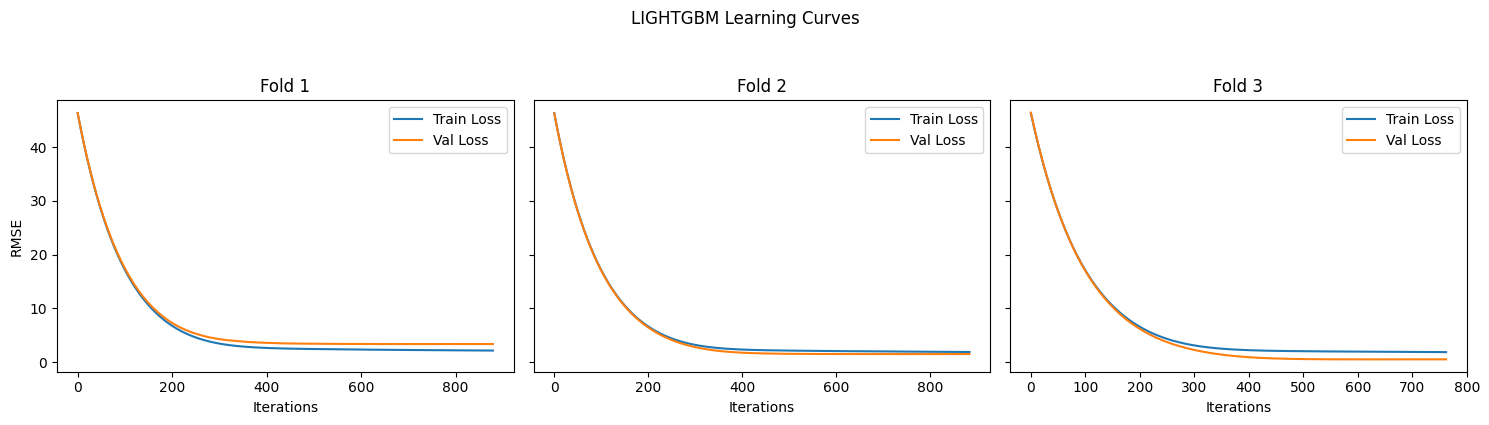

In [9]:
from src.train import run_experiment

results_lgb = run_experiment(
    exp_id='001',
    model_name='lightgbm',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v1',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
)

### 4.2 CatBoost

Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)

Fold 0 — catboost
  Train: 46772 rows, Valid: 16425 rows
0:	learn: 44.4790304	test: 44.4885991	best: 44.4885991 (0)	total: 416ms	remaining: 13m 50s
100:	learn: 2.8412375	test: 1.0464815	best: 1.0464815 (100)	total: 18.7s	remaining: 5m 52s
200:	learn: 2.5240061	test: 1.0145553	best: 0.9651028 (140)	total: 36.6s	remaining: 5m 27s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9651028064
bestIteration = 140

Shrink model to first 141 iterations.
[Fold 0] RMSE: 0.965103 | MAE: 0.646095 | R2: 0.999574
Fold 1: train=63197 (2023-01-01 -> 2024-12-31), valid=14015 (2025-01-01 -> 2025-06-30)

Fold 1 — catboost
  Train: 63197 rows, Valid: 14015 rows
0:	learn: 44.4709343	test: 44.4067079	best: 44.4067079 (0)	total: 165ms	remaining: 5m 29s
100:	learn: 2.4760854	test: 1.5360164	best: 1.5360164 (100)	total: 20.9s	remaining: 6m 32s
200:	learn: 2.1270324	test: 1.4671389	best: 1.4671389 (200)	to

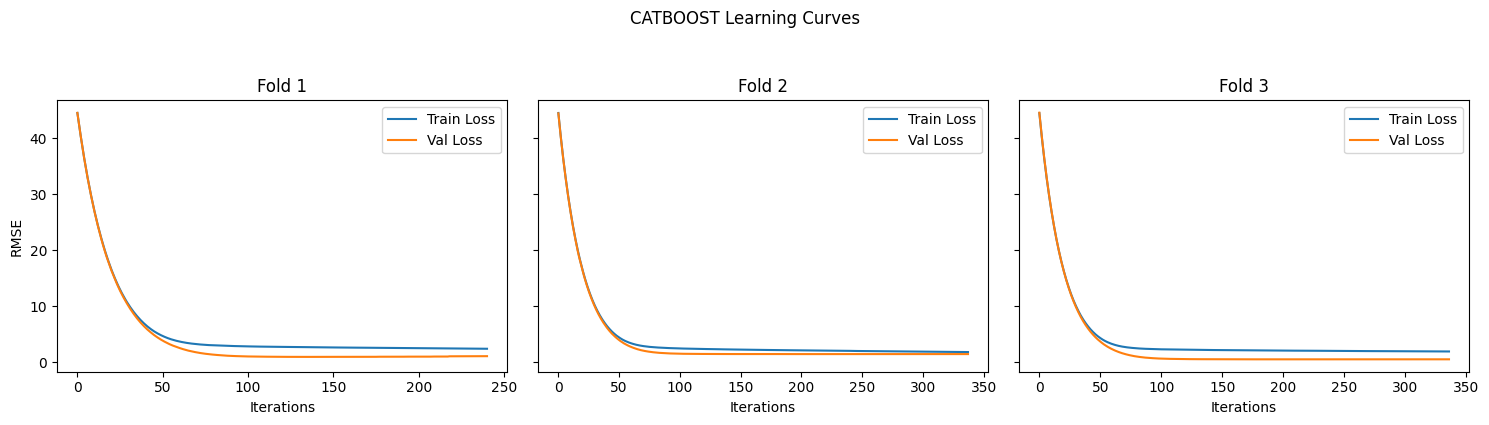

In [10]:
results_cb = run_experiment(
    exp_id='002',
    model_name='catboost',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v1',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
)

### 4.3 XGBoost

Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)

Fold 0 — xgboost
  Train: 46772 rows, Valid: 16425 rows
[Fold 0] RMSE: 4.942651 | MAE: 1.606583 | R2: 0.988814
Fold 1: train=63197 (2023-01-01 -> 2024-12-31), valid=14015 (2025-01-01 -> 2025-06-30)

Fold 1 — xgboost
  Train: 63197 rows, Valid: 14015 rows
[Fold 1] RMSE: 1.769672 | MAE: 0.813592 | R2: 0.998564
Fold 2: train=77212 (2023-01-01 -> 2025-06-30), valid=7184 (2025-07-01 -> 2025-09-18)

Fold 2 — xgboost
  Train: 77212 rows, Valid: 7184 rows
[Fold 2] RMSE: 0.772693 | MAE: 0.406343 | R2: 0.999728

MEAN CV — xgboost
[Mean] RMSE: 2.495005 | MAE: 0.942173 | R2: 0.995702
Time: 172.3s
Experiment 003 logged -> D:\Lomba\SSDS\Mandiri\outputs\experiment_log.csv
Model saved -> D:\Lomba\SSDS\Mandiri\models\xgboost.joblib


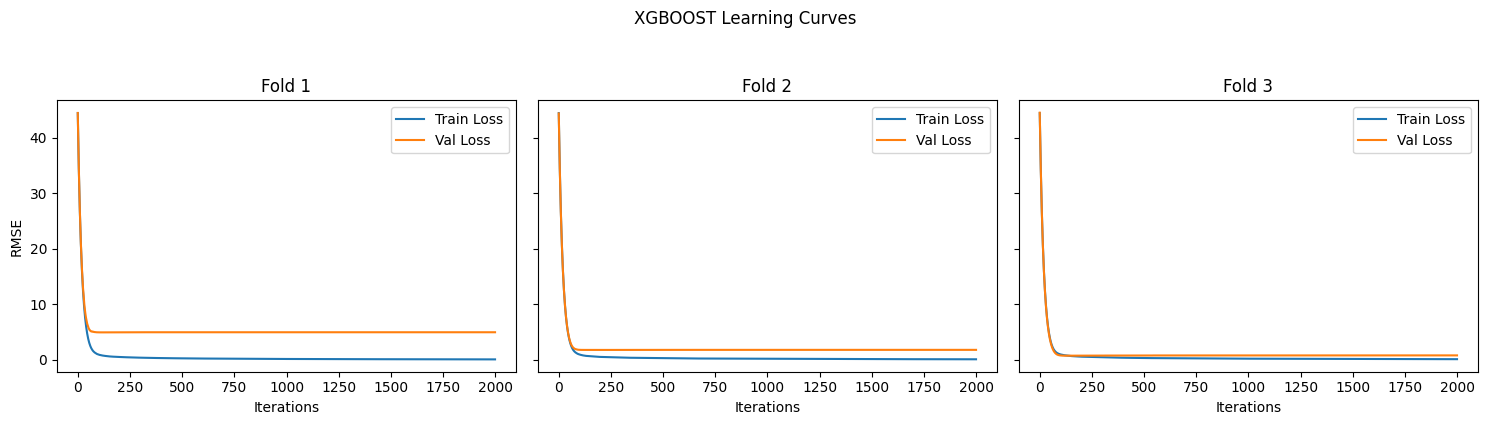

In [11]:
results_xgb = run_experiment(
    exp_id='003',
    model_name='xgboost',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v1',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
)

---
## Step 5: Model Comparison

In [12]:
from src.train import compare_models

all_results = {
    'LightGBM': results_lgb,
    'CatBoost': results_cb,
    'XGBoost': results_xgb,
}

comparison = compare_models(all_results)
print('\nModel Comparison (by RMSE):')
comparison


Model Comparison (by RMSE):


,model,rmse,rmse_std,mae,mae_std,r2,r2_std,time_s
0,CatBoost,0.985,0.384,0.580,0.152,0.999,0.000,186.600
1,LightGBM,1.812,1.181,0.834,0.430,0.998,0.002,40.000
2,XGBoost,2.495,1.778,0.942,0.498,0.996,0.005,172.300


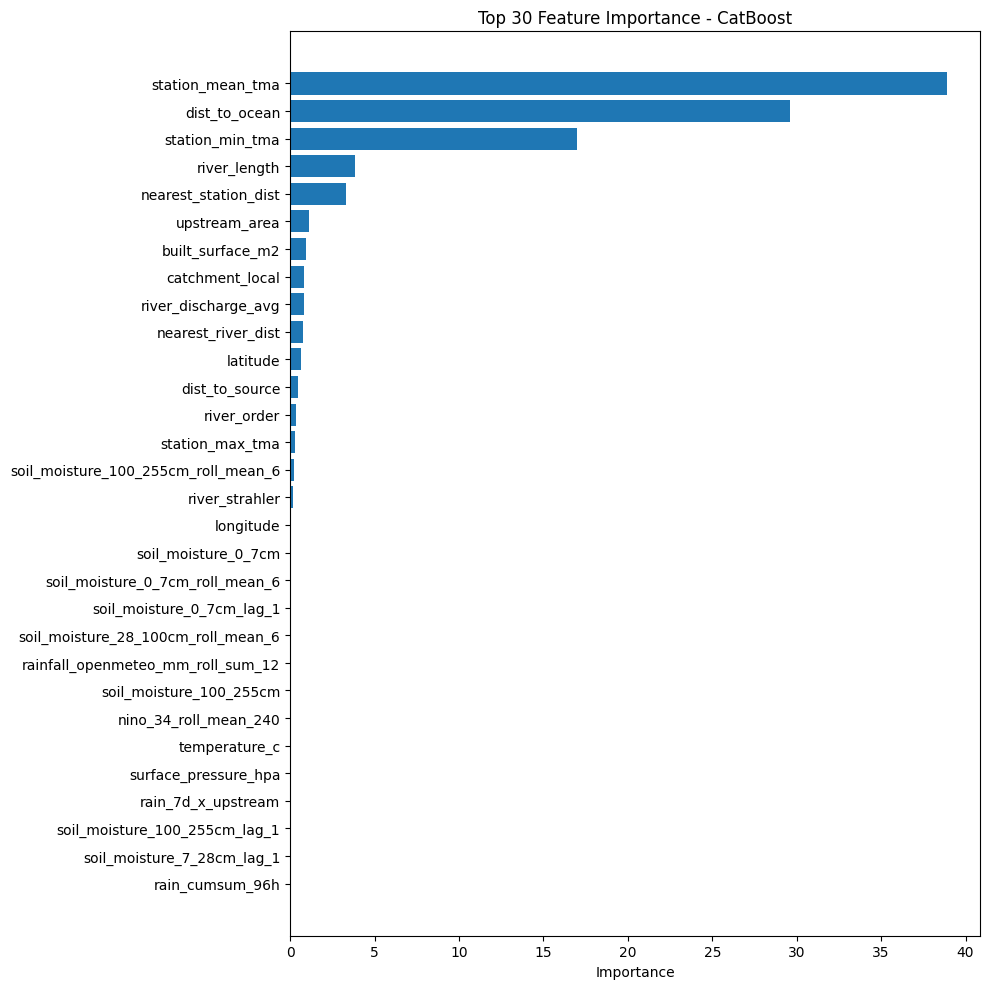

In [13]:
# Feature importance from best model
best_model_name = comparison.iloc[0]['model']
best_results = all_results[best_model_name]

feat_imp = best_results['feature_importance'].head(30)

plt.figure(figsize=(10, 10))
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1])
plt.title(f'Top 30 Feature Importance - {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## Step 6: Ensemble & Submission

Train best models on full data, then ensemble for final submission.

In [ ]:
from src.train import train_full
from src.inference import predict_test, ensemble_predictions, build_submission

# Train best models on FULL training data
model_lgb_full = train_full('lightgbm', master_train, feature_cols, cat_features)
model_cb_full = train_full('catboost', master_train, feature_cols, cat_features)
model_xgb_full = train_full('xgboost', master_train, feature_cols, cat_features)

Training lightgbm on full data: 84396 rows...
Done.
Training catboost on full data: 84396 rows...


You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 44.4529299	total: 817ms	remaining: 27m 12s
100:	learn: 2.2089756	total: 25.6s	remaining: 8m 1s
200:	learn: 1.9480957	total: 51.5s	remaining: 7m 41s
300:	learn: 1.8006454	total: 1m 11s	remaining: 6m 46s
400:	learn: 1.6760930	total: 1m 33s	remaining: 6m 14s
500:	learn: 1.5588685	total: 1m 56s	remaining: 5m 48s
600:	learn: 1.4668617	total: 2m 21s	remaining: 5m 28s
700:	learn: 1.3710277	total: 2m 47s	remaining: 5m 11s
800:	learn: 1.2841715	total: 3m 13s	remaining: 4m 49s
900:	learn: 1.2120325	total: 3m 34s	remaining: 4m 21s


In [ ]:
# Ensure test feature columns match train
test_feature_cols = [c for c in feature_cols if c in master_test_featured.columns]
print(f'Test features available: {len(test_feature_cols)} / {len(feature_cols)}')

# Generate predictions
preds_lgb = predict_test(model_lgb_full, master_test_featured, test_feature_cols)
preds_cb = predict_test(model_cb_full, master_test_featured, test_feature_cols)
preds_xgb = predict_test(model_xgb_full, master_test_featured, test_feature_cols)

print('\nPredictions generated for all models.')

Test features available: 101 / 101

Predictions generated for all models.


In [ ]:
# Ensemble with weights (adjust based on CV performance)
ensemble_preds = ensemble_predictions(
    predictions_dict={
        'LightGBM': preds_lgb,
        'CatBoost': preds_cb,
        'XGBoost': preds_xgb,
    },
    weights={
        'LightGBM': 0.40,
        'CatBoost': 0.35,
        'XGBoost': 0.25,
    },
)

ensemble_preds.head()

Ensemble weights:
  LightGBM: 0.400
  CatBoost: 0.350
  XGBoost: 0.250


,id,tma_mdpl
2903,2025-09-19 06:00:00 - Arjowinangun - Pacitan,0.957
2904,2025-09-19 12:00:00 - Arjowinangun - Pacitan,0.977
2905,2025-09-19 18:00:00 - Arjowinangun - Pacitan,0.840
2906,2025-09-20 06:00:00 - Arjowinangun - Pacitan,0.974
2907,2025-09-20 12:00:00 - Arjowinangun - Pacitan,1.082


In [ ]:
# Save ensemble submission
build_submission(ensemble_preds, filename='submission_ensemble_v1.csv')

# Also save individual model submissions
build_submission(preds_lgb, filename='submission_lgb_v1.csv')
build_submission(preds_cb, filename='submission_cb_v1.csv')
build_submission(preds_xgb, filename='submission_xgb_v1.csv')

Submission saved -> D:\Lomba\SSDS\Mandiri\outputs\submission_ensemble_v1.csv
  Shape: (21780, 2)
  TMA stats: mean=55.524, std=46.701, min=0.686, max=146.339
Submission saved -> D:\Lomba\SSDS\Mandiri\outputs\submission_lgb_v1.csv
  Shape: (21780, 2)
  TMA stats: mean=55.503, std=46.742, min=0.383, max=146.403
Submission saved -> D:\Lomba\SSDS\Mandiri\outputs\submission_cb_v1.csv
  Shape: (21780, 2)
  TMA stats: mean=55.556, std=46.645, min=0.422, max=147.288
Submission saved -> D:\Lomba\SSDS\Mandiri\outputs\submission_xgb_v1.csv
  Shape: (21780, 2)
  TMA stats: mean=55.514, std=46.725, min=0.732, max=146.212


WindowsPath('D:/Lomba/SSDS/Mandiri/outputs/submission_xgb_v1.csv')

---
## Step 7: Experiment Log

Track all experiments for reproducibility.

In [ ]:
from src.utils import load_experiment_log

exp_log = load_experiment_log()
if not exp_log.empty:
    display(exp_log)
else:
    print('No experiments logged yet.')

,exp_id,features,model,cv_mean,cv_std,cv_folds,lb_score,notes
0,1,All_v1,lightgbm,0.956,0.640,"[np.float64(1.056709), np.float64(1.684889), n...",NaN,"params={'objective': 'regression', 'metric': '..."
1,1,All_v1,lightgbm,0.956,0.640,"[np.float64(1.056709), np.float64(1.684889), n...",NaN,"params={'objective': 'regression', 'metric': '..."
2,2,All_v1,catboost,0.855,0.566,"[np.float64(0.757036), np.float64(1.591985), n...",NaN,"params={'iterations': 2000, 'learning_rate': 0..."
3,3,All_v1,xgboost,0.877,0.413,"[np.float64(0.933116), np.float64(1.352093), n...",NaN,"params={'objective': 'reg:squarederror', 'eval..."
4,1,All_v1,lightgbm,1.823,1.106,"[np.float64(3.307925), np.float64(1.503556), n...",NaN,"params={'objective': 'regression', 'metric': '..."
5,2,All_v1,catboost,3.485,2.982,"[np.float64(7.578718), np.float64(2.312099), n...",NaN,"params={'iterations': 2000, 'learning_rate': 0..."
6,3,All_v1,xgboost,3.760,2.402,"[np.float64(7.13238), np.float64(2.429391), np...",NaN,"params={'objective': 'reg:squarederror', 'eval..."
7,1,All_v1,lightgbm,1.663,0.949,"[np.float64(2.883678), np.float64(1.533671), n...",NaN,"params={'objective': 'regression', 'metric': '..."
8,1,All_v1,lightgbm,1.663,0.949,"[np.float64(2.883678), np.float64(1.533671), n...",NaN,"params={'objective': 'regression', 'metric': '..."
9,2,All_v1,catboost,3.334,2.953,"[np.float64(7.420234), np.float64(2.033424), n...",NaN,"params={'iterations': 2000, 'learning_rate': 0..."


# 7. Run Deep Learning Models (Experimental)

In [ ]:
# Run PatchTST (Transformer)
results_patchtst = run_experiment(
    exp_id='DL_01',
    model_name='patchtst',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_Max_Spatial',
    cv=cv,
    categorical_features=cat_features,
    model_params=None,
    save_model=False,
    verbose=True
)

# Run ST-GNN (Spatio-Temporal Graph Neural Network)
results_stgnn = run_experiment(
    exp_id='DL_02',
    model_name='st-gnn',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_Max_Spatial',
    cv=cv,
    categorical_features=cat_features,
    model_params=None,
    save_model=False,
    verbose=True
)

ValueError: Unknown model 'patchtst'. Available: ['lightgbm', 'catboost', 'xgboost', 'random_forest']